In [47]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
from scipy.special import factorial
import re

A incerteza da grandeza $f$, $\sigma_f$, que depende das variáveis $(x_1,\,\dots,\,x_n) \in \mathbb{R}$ é
$$\sigma_f^2 = \sum_{j=1}^n \partial _{x_j} f \,\sigma_{x_j}$$

Para calcular $\mu$ e $\sigma$ foram usadas as seguintes fórmulas:
No caso de ser usado um ajuste a uma função gaussiana, é feito simplesmente o ajuste e $\mu=\mu_{fit}$ e $\sigma = \sigma_{fit}/\sqrt{N_{total}}$. 
Caso contrário, 
$$\mu = \frac{1}{N_{total}}\sum_nCN$$
$$\sigma = \frac{1}{N_{total}}\sqrt{\sum_n(C-\mu)^2N}$$

In [48]:
def load_spectrum(path):

    text = Path(path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []

    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def poisson(x, lamb):
    return (lamb ** x) * np.exp(-lamb) / factorial(x)

def compute_chi2(o, e, dof=None):
    mask = e > 0
    chi2 = np.sum(((o[mask] - e[mask]) ** 2) / e[mask])
    if dof is not None:
        return chi2 / dof
    return chi2

def compute_stat(canais, contagens, model=None):
    c = np.array(canais)
    N = np.array(contagens)

    N_t = np.sum(N)
    if N_t == 0:
        return 0, 0, None
    
    match model:
        case 'gaussian':
            popt, _ = optimize.curve_fit(gaussian, c, N, p0=[N_t, c[np.argmax(N)], np.std(c)])
            mu = popt[1]
            sigma = popt[2]/np.sqrt(N_t)
            y_fit = gaussian(c, *popt)
            dof = len(c) - 3
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case 'poisson':
            popt, _ = optimize.curve_fit(poisson, c, N, p0=[N_t/len(canais)])
            mu = popt[0]
            sigma = np.sqrt(mu/N_t)
            y_fit = poisson(c, *popt)
            dof = len(c) - 1
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case None:
            mu = np.sum(c * N) / N_t    
            sigma = np.sqrt(np.sum((c - mu) ** 2 * N)) / N_t

            return mu, sigma, float('nan')           

def linear(x, m, b):
    return m * x + b 

def calculate_centroid(canais, contagens):
    """Calculate centroid (weighted average) of a peak."""
    canais = np.array(canais)
    contagens = np.array(contagens)
    
    if np.sum(contagens) == 0:
        return 0, 0
        
    centroid = np.sum(canais * contagens) / np.sum(contagens)
    # Estimate sigma from peak width
    sigma = np.sqrt(np.sum((canais - centroid)**2 * contagens) / np.sum(contagens))
    
    return centroid, sigma


## Espetro de Césio

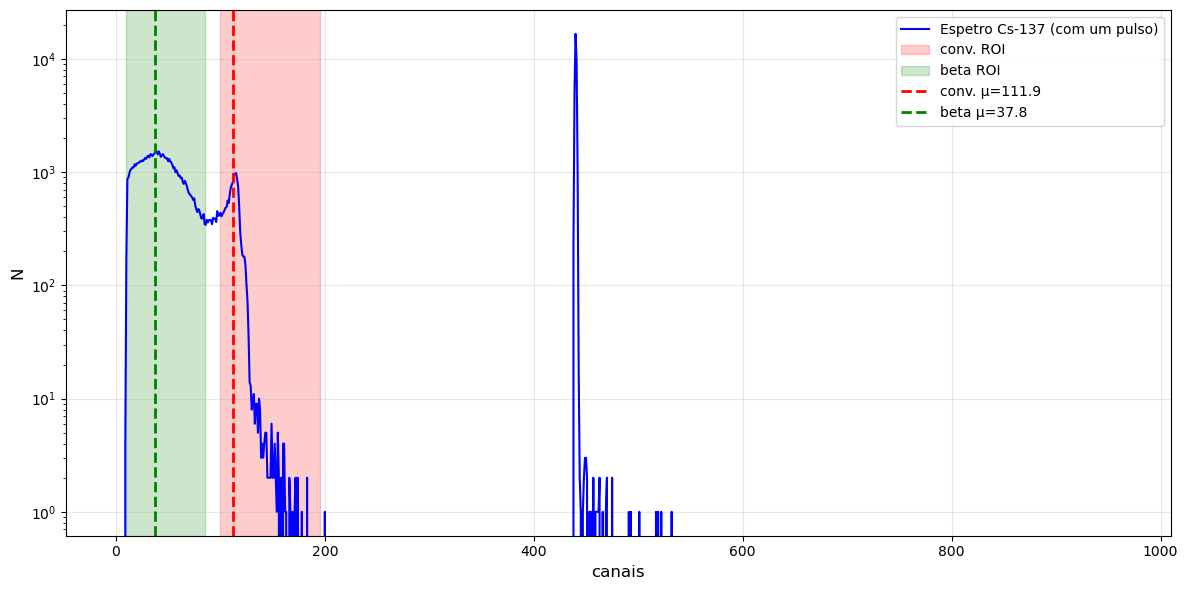

Conversão: 
  μ = 111.8793 ± 0.0600; χ² = nan
Beta: 
  μ = 37.8220 ± 0.0936; χ² = 10.2387


In [49]:
channels_cs, counts_cs = load_spectrum('CPR1.ASC')

cs_conv_min, cs_conv_max = 100, 195
cs_beta_min, cs_beta_max = 10, 85
cs_conv_roi = slice(cs_conv_min, cs_conv_max)
cs_beta_roi = slice(cs_beta_min, cs_beta_max)
cs_conv_mu, cs_conv_sigma, cs_conv_chi2 = compute_stat(channels_cs[cs_conv_roi], counts_cs[cs_conv_roi], model=None)
cs_beta_mu, cs_beta_sigma, cs_beta_chi2 = compute_stat(channels_cs[cs_beta_roi], counts_cs[cs_beta_roi], model='gaussian')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_cs, counts_cs, 'b-', linewidth=1.5, label='Espetro Cs-137 (com um pulso)')
ax.axvspan(cs_conv_min, cs_conv_max, alpha=0.2, color='red', label='conv. ROI')
ax.axvspan(cs_beta_min, cs_beta_max, alpha=0.2, color='green', label='beta ROI')
ax.axvline(cs_conv_mu, color='red', linestyle='--', linewidth=2, label=f'conv. μ={cs_conv_mu:.1f}')
ax.axvline(cs_beta_mu, color='green', linestyle='--', linewidth=2, label=f'beta μ={cs_beta_mu:.1f}')
ax.set_yscale('log')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Conversão: \n  μ = {cs_conv_mu:.4f} ± {cs_conv_sigma:.4f}; χ² = {cs_conv_chi2:.4f}")
print(f"Beta: \n  μ = {cs_beta_mu:.4f} ± {cs_beta_sigma:.4f}; χ² = {cs_beta_chi2:.4f}")

In [50]:
dados_arquivos = {
    'Pulser02.asc': (0, 1024), 'Pulser04.asc': (0, 1024), 'Pulser06.asc': (0, 1024),
    'Pulser08.asc': (0, 1024), 'Pulser10.asc': (0, 1024), 'Pulser12.asc': (0, 1024)
}

centroides_p = []
erros_centroide_p = []

print("--- 1. Estatística dos Picos (Pulsers) ---")
for arquivo, (c_min, c_max) in dados_arquivos.items():
    try:
        canais, contagens = load_spectrum(arquivo)
        mascara = (canais >= c_min) & (canais <= c_max)
        
        c_roi, n_roi = canais[mascara], contagens[mascara]
        centroide_pulser, sigma_pulser = calculate_centroid(c_roi, n_roi)
        
        # Erro padrão da posição do centroide
        erro_c = sigma_pulser / np.sqrt(np.sum(n_roi))
        
        centroides_p.append(centroide_pulser)
        erros_centroide_p.append(erro_c)
        
        print(f"{arquivo} -> Centroide: {centroide_pulser:.2f} | \u03c3 (Largura): {sigma_pulser:.4f} | Erro Padrão: {erro_c:.6f}")
    except FileNotFoundError:
        print(f"Ficheiro {arquivo} não encontrado.")

--- 1. Estatística dos Picos (Pulsers) ---
Pulser02.asc -> Centroide: 41.38 | σ (Largura): 0.9566 | Erro Padrão: 0.023715
Pulser04.asc -> Centroide: 86.95 | σ (Largura): 2.5865 | Erro Padrão: 0.064065
Pulser06.asc -> Centroide: 129.62 | σ (Largura): 0.7681 | Erro Padrão: 0.019043
Pulser08.asc -> Centroide: 172.41 | σ (Largura): 2.6267 | Erro Padrão: 0.065101
Pulser10.asc -> Centroide: 217.78 | σ (Largura): 4.9831 | Erro Padrão: 0.123463
Pulser12.asc -> Centroide: 263.35 | σ (Largura): 5.6824 | Erro Padrão: 0.140789


Com base nos dados do pulser obtemos a reta de calibração para pulser

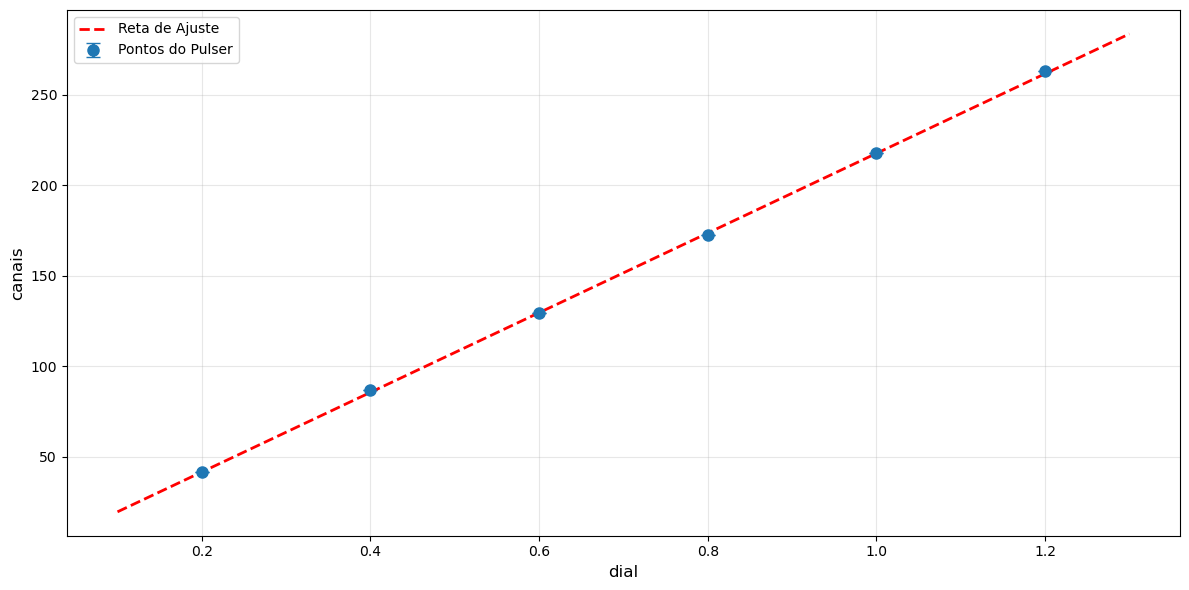

m_p = 220.275293 ± 1.002414 canais/dial
b_p = -2.57 ± 0.52 canais
χ²_red = 0.0105


In [51]:
pulser_C = np.array(centroides_p)
pulser_C_sigma = np.array(erros_centroide_p)
pulser_D = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])

popt, pcov = optimize.curve_fit(linear, pulser_D, pulser_C, sigma=pulser_C_sigma)
perr = np.sqrt(np.diag(pcov))

pulser_C_fit = linear(pulser_D, *popt)

chi2 = compute_chi2(pulser_C, pulser_C_fit, dof=len(pulser_C) - 2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(pulser_D, pulser_C, yerr=pulser_C_sigma, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pontos do Pulser')
D_plot = np.linspace(pulser_D.min() - 0.1, pulser_D.max() + 0.1, 100)
ax.plot(D_plot, linear(D_plot, *popt), 'r--', linewidth=2, label=f'Reta de Ajuste')
ax.set_xlabel('dial', fontsize=12)
ax.set_ylabel('canais', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"m_p = {popt[0]:.6f} ± {perr[0]:.6f} canais/dial")
print(f"b_p = {popt[1]:.2f} ± {perr[1]:.2f} canais")
print(f"χ²_red = {chi2:.4f}")

Agora traduzindo de dials para MeV, pegamos no pico de conversão do Cs-137, $C_{Cs}$,
$$D_{Cs} = \frac{C_{Cs} - b_p}{m_p}$$
Como o pulser é linear para a energia, ou seja, $D = 0 \implies E = 0\text{ MeV}$, temos a relação linear
$$ E_j = \kappa D_j $$
e podemos calcular $\kappa$, usando o pico conhecido, $\kappa = E_{Cs}/D_{Cs} $, onde $E_{Cs} = 624.215
\text{ keV}$ 

Assim, temos a nossa reta de calibração de canais para energia, $E$
$$
E = \frac{\kappa}{m_p}C - \frac{\kappa b_p}{m_p} = mC - b
$$



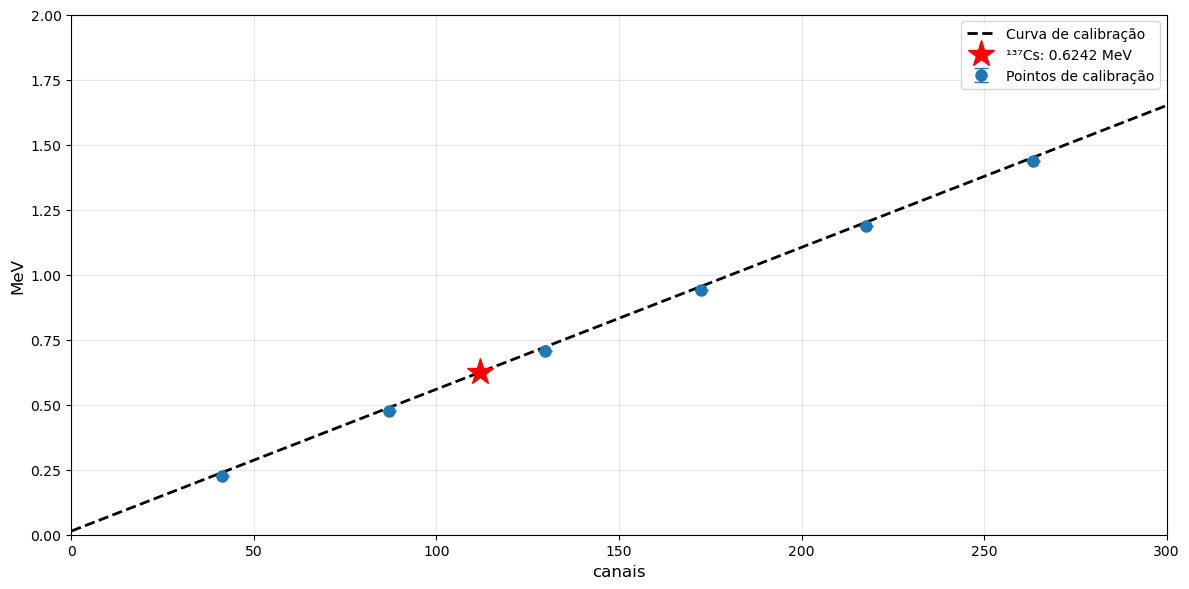

m = 0.005454 ± 0.000043 MeV/ch
b = 0.014004 ± 0.002850 MeV


In [52]:
cs_conv_ene = 0.624215 #MeV

cs_conv_dial = (cs_conv_mu - popt[1]) / popt[0]
cs_conv_dial_sigma = np.sqrt((cs_conv_sigma / popt[0]) ** 2 + ((cs_conv_mu - popt[1]) * perr[0] / popt[0] ** 2) ** 2 + (perr[1] / popt[0]) ** 2)

kappa = cs_conv_ene / cs_conv_dial
kappa_sigma = np.abs(cs_conv_ene / cs_conv_dial ** 2) * cs_conv_dial_sigma

pulser_energies = kappa * pulser_D
#A incerteza dos dials é 0.01, menor divisão da escala
pulser_energies_sigma = np.sqrt((kappa_sigma * pulser_D) ** 2 + (kappa * 0.01) ** 2)

m = kappa/ popt[0]
m_sigma = np.sqrt((perr[0] * kappa/ popt[0]**2) ** 2 + (kappa_sigma/popt[0]) ** 2)
b = -popt[1] * kappa/popt[0]
b_sigma = np.sqrt((perr[1] * kappa / popt[0]) ** 2 + (popt[1] * kappa_sigma / popt[0]) ** 2 + (popt[1] * kappa * perr[0] / popt[0] ** 2) ** 2)

channels_plot = np.linspace(0, 1200, 1000)
energy_plot = m * channels_plot + b

pulser_energies_calib = m * pulser_C

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_plot, energy_plot, 'k--', linewidth=2, label='Curva de calibração')
ax.set_xlim(0, 300)
ax.set_ylim(0, 2)
ax.errorbar(pulser_C, pulser_energies_calib, yerr=pulser_C_sigma * m, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pointos de calibração')
ax.plot(cs_conv_mu, cs_conv_ene, 'r*', markersize=20, label=f'¹³⁷Cs: {cs_conv_ene:.4f} MeV')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('MeV', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"m = {m:.6f} ± {m_sigma:.6f} MeV/ch")
print(f"b = {b:.6f} ± {b_sigma:.6f} MeV")
